In [1]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin

In [2]:
#function
#ABS
def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))

    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD(H_q,H_l,H_r,  T_12,T_LD,T_l,T_RD,T_r,  N,E,eta=3e-6):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(E + 1j*eta)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E + 1j*eta)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T
    A_DD = np.block(A_DD)
    G_DD_r = np.linalg.inv(A_DD)
    return G_DD_r , A_DD ,Sigma_R ,Sigma_L 
    
def bufeng(G_DD_r):
    d = H_q.shape[0]
    yigeshu=np.trace(G_DD_r[q*d:(q+1)*d, (q)*d:(q+1)*d])
    return -np.imag(yigeshu)/np.pi

def find_peaks_fmin(A_of_E, E_min, E_max, N_guess=11, xtol=1e-6, ftol=1e-6, round_digits=6):

    E_guesses = np.linspace(E_min, E_max, N_guess)
    peak_list = []

    for E0 in E_guesses:
        r = fmin(lambda E: -A_of_E(E), E0, disp=False, xtol=xtol, ftol=ftol)
        peak_list.append(r[0])

    peak_list = np.unique(np.round(peak_list, round_digits))
    return peak_list


#current1
def Gr_DD_MS(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, wn):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(1j*wn)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (1j*wn)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    A_DD_wn = np.block(A_DD)
    G_DD_wn = np.linalg.inv(A_DD_wn)
    return G_DD_wn , A_DD_wn , Sigma_R , Sigma_L 

def Gr_DD_MS_gaiyixia(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, wn):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(1j*wn)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (1j*wn)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    A_DD_wn = np.block(A_DD)
    G_DD_wn = np.linalg.inv(A_DD_wn)

    f_E= 1/(1+np.exp((1j*wn - mu)/KBT))
    G_DD_wn_xiao=f_E*(G_DD_wn.conj().T-G_DD_wn)
    return G_DD_wn_xiao , A_DD_wn , Sigma_R , Sigma_L 

def J_wn(G_DD_wn, T_12, q):
    d = T_12.shape[0]

    G_q_q1 = G_DD_wn[q*d:(q+1)*d, (q+1)*d:(q+2)*d]
    G_q1_q = G_DD_wn[(q+1)*d:(q+2)*d, q*d:(q+1)*d]

    Jmat = T_12.conj().T @ G_q_q1 - G_q1_q @ T_12
    d_e = d //2
    return np.trace(Jmat[:d_e, :d_e])*(-1j)*KBT*(-1)
    #return np.trace(Jmat)*(-1j)*KBT

def matsubara_list(shumu):
    n_max =  shumu
    n_vals = np.arange(-n_max, n_max+1 )
    wn = (2 * n_vals + 1) * np.pi * KBT

    return wn.tolist()

def J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N, q):
    wn_list = matsubara_list(shumu)
    J_sum = 0.0 
    for wn in wn_list:
        G_DD_wn, _, _, _ = Gr_DD_MS(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, wn
        )

        J_sum += np.real(J_wn(G_DD_wn, T_12, q))
    return (J_sum)



In [3]:
#参数1
dela = 1
chaodaojiao = 0
m=2.5*10**(-3)
a=1
t =1/(2*m*a**2)
af =100
mu = 0


my=0.5
mz=0.5
#(my = 0.954776)

T_Tc=1e-1
Delta = dela# * np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))

N=2
q=0
dianshubei=1
shumu=int(np.floor(5/ T_Tc))*dianshubei
KBT=2 * dela * T_Tc / 3.5

#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

def H_onsite(my,mz,weizhi,chaodaojiao,renyixiang=0):
    if weizhi==1:
        Delta_X=- Delta * np.exp(1j*renyixiang) * 1j * sy
    elif weizhi==2:
        Delta_X=np.zeros((2,2))
    elif weizhi==3:
        Delta_X=- Delta * np.exp(-1j*chaodaojiao) * 1j * sy
    HX_block=-(mu-2*t)*s0 + my*sy + mz*sz
    return np.block([
        [ HX_block,        Delta_X       ],
        [ Delta_X.conj().T, -HX_block.conj() ]
    ])
def H_hop(af):
    H_X_right_to_left_hop_block=-1*(t*s0+1j*af*sy/(2*a))
    return np.block([
        [ H_X_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_X_right_to_left_hop_block.conj() ]
    ])
#左边矩阵信息
H_L_onsite=H_onsite(my,mz,1,chaodaojiao)
H_L_right_to_left_hop=H_hop(af)

#中间矩阵信息
H_center_to_L=H_hop(af)

H_center=H_onsite(my,mz,2,chaodaojiao)
H_center_right_to_left_hop=H_hop(af)

H_R_to_center=H_hop(af)

#右边矩阵信息
H_R_onsite=H_onsite(my,mz,3,chaodaojiao)
H_R_right_to_left_hop=H_hop(af)


#输入矩阵
H_q=H_center
T_12= H_center_right_to_left_hop.conj().T

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L.conj().T
T_RD= H_R_to_center


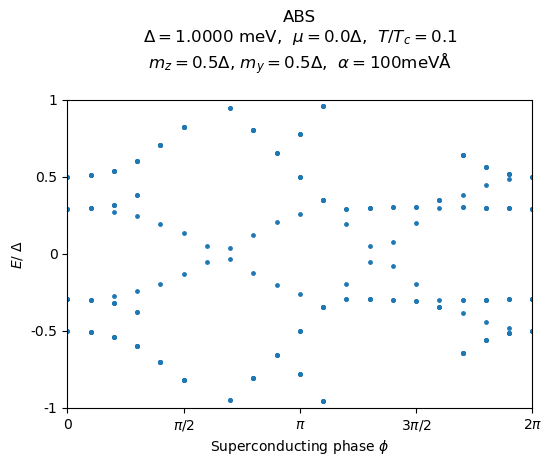

In [4]:
phi_set = np.linspace(0, 2*np.pi, 21)     # 超导相位
sdsd=1
E_min, E_max = -Delta *sdsd, Delta *sdsd

phi_list = []
E_peak_list = []

for phi in phi_set:
    chaodaojiao = phi
    H_r = H_onsite(my,mz,3,chaodaojiao)
    def A_of_E(E):
        G_DD_r, _, _, _ = Gr_DD(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, E
        )
        return bufeng(G_DD_r)


    peak_energies = find_peaks_fmin(A_of_E, E_min, E_max, N_guess=20, xtol=1e-5, ftol=1e-5)


    for E_peak in peak_energies:
        phi_list.append(phi)
        E_peak_list.append(E_peak)


plt.figure(figsize=(6,4))
plt.scatter(phi_list, E_peak_list, s=6)
plt.xlabel(r"Superconducting phase $\phi$")
plt.title(
    f'ABS\n'
    f'$\\Delta = {dela:.4f}$ meV,  $\\mu = {mu/dela:.1f}\\Delta$,  $T/T_c = {T_Tc}$\n'
    f'$m_z = {mz}\\Delta$, $m_y = {my}\\Delta$,  $\\alpha = {af}$meVÅ\n'
    
)
plt.ylabel(r"$E$/ $\Delta$")
plt.xlim(0, 2*np.pi)
#plt.ylim(E_min, E_max)
plt.ylim(E_min, E_max)
plt.yticks(
    [-Delta, -Delta/2, 0, Delta/2, Delta],
    [-1*sdsd, -1*sdsd/2, 0, 1*sdsd/2, 1*sdsd]
)
plt.xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
)
plt.show()


<>:43: SyntaxWarning: invalid escape sequence '\D'
<>:43: SyntaxWarning: invalid escape sequence '\D'
C:\Users\taoji\AppData\Local\Temp\ipykernel_29780\2809687848.py:43: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('E/$\Delta$')


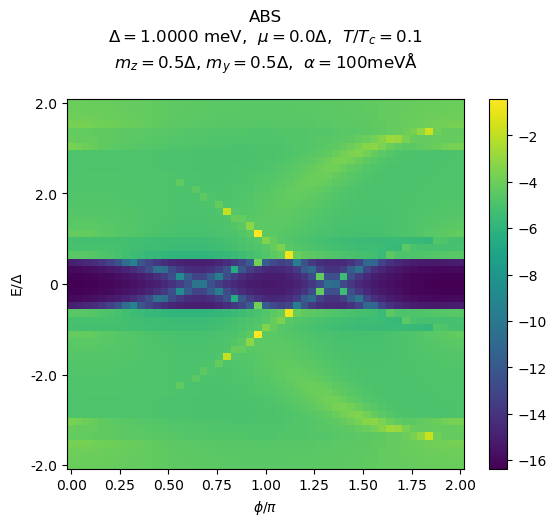

In [5]:
#ABS
num_ef = 50
efmin = -Delta*2
efmax = Delta*2
def_ = (efmax - efmin) / num_ef
num_phi = 50
phi_min = 0
phi_max = 2 * np.pi
dphi = (phi_max - phi_min) / num_phi

# Initialize grids
ef_plot = np.zeros(num_ef + 1)
phi_plot = np.zeros(num_phi + 1)
ABS = np.zeros((num_ef + 1, num_phi + 1))

for jj in range(num_ef + 1):
    ef = efmin + def_ * jj
    ef_plot[jj] = ef
    for ii in range(num_phi + 1):
        phi = phi_min + dphi * ii
        phi_plot[ii] = phi / np.pi
        
        # Update Delta and H_l, H_r based on phi
        H_r = H_onsite(my,mz,3,phi)
        
        # Compute G_DD_r
        G_DD_r, _, _, _ = Gr_DD(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, ef
        )
        
        # Compute ABS (bufeng)
        ABS[jj, ii] = bufeng(G_DD_r)

# Figure
plt.figure()
X, Y = np.meshgrid(phi_plot, ef_plot)
plt.pcolormesh(X, Y, np.log(ABS + 1e-10), shading='auto')  # Added small epsilon to avoid log(0)
plt.colorbar(location='right')
plt.xlabel(r'$\phi$/$\pi$')

plt.ylabel('E/$\Delta$')
plt.yticks(
    [efmin, efmin/2, 0,efmax/2, efmax],
    [efmin/Delta, efmin/Delta, 0,efmax/Delta, efmax/Delta]
)
plt.title(
    f'ABS\n'
    f'$\\Delta = {dela:.4f}$ meV,  $\\mu = {mu/dela:.1f}\\Delta$,  $T/T_c = {T_Tc}$\n'
    f'$m_z = {mz}\\Delta$, $m_y = {my}\\Delta$,  $\\alpha = {af}$meVÅ\n'
    
)
plt.axis('square')
plt.axis('tight')
plt.show()

In [ ]:
def J_of_phi(phi):
    H_l = H_onsite(my,mz,1,phi)
    H_q = H_onsite(my,mz,2,phi)
    H_r = H_onsite(my,mz,3,phi)
    Jphi = J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N, q)
    return Jphi
    
def find_J_extreme_fmin(phi_min=0*np.pi, phi_max=2*np.pi,
                       N_guess=4, xtol=1e-3, ftol=1e-3,
                       round_digits=6):

    phi_guesses = np.linspace(phi_min, phi_max, N_guess)

    max_list = []
    min_list = []

    for phi0 in phi_guesses:

        # 最大值
        rmax = fmin(lambda phi: -J_of_phi(phi), phi0,
                    disp=False, xtol=xtol, ftol=ftol)
        max_list.append(rmax[0])

        # 最小值
        rmin = fmin(lambda phi: J_of_phi(phi), phi0,
                    disp=False, xtol=xtol, ftol=ftol)
        min_list.append(rmin[0])

    phi_max_list = np.unique(np.round(max_list, round_digits))
    phi_min_list = np.unique(np.round(min_list, round_digits))

    J_max = max(J_of_phi(phi) for phi in phi_max_list)
    J_min = min(J_of_phi(phi) for phi in phi_min_list)


    J_max = -np.inf
    phi_at_Jmax = None

    for phi in phi_max_list:
        val = J_of_phi(phi)
        if val > J_max:
            J_max = val
            phi_at_Jmax = phi

    J_min = np.inf
    phi_at_Jmin = None

    for phi in phi_min_list:
        val = J_of_phi(phi)
        if val < J_min:
            J_min = val
            phi_at_Jmin = phi

    yinzi =abs(abs(J_max) - abs(J_min)) / (abs(J_max) + abs(J_min))

    return J_max, phi_at_Jmax, J_min, phi_at_Jmin, yinzi

J_of_phi(0),J_of_phi(np.pi),J_of_phi(2*np.pi)

(-0.018665379936844972, 0.059834914485270105, -0.01866537993684891)

In [7]:
shumu=int(np.floor(5 / T_Tc))*dianshubei
print('n*2*np.pi*KBT/Delta=',shumu*2*np.pi*KBT/Delta)
jjalpi=J_of_phi(0.5*np.pi)
print('这时J(phi/2)=',jjalpi)

shumu=int(np.floor(5/ T_Tc))*dianshubei+1
print('n*2*np.pi*KBT/Delta=',shumu*2*np.pi*KBT/Delta)
jjalpi2=J_of_phi(0.5*np.pi)
print('这时J(phi/2)=',jjalpi2)


alnalkna=abs(abs(jjalpi2)-abs(jjalpi))/(abs(jjalpi2)+abs(jjalpi))
print('因子差=',alnalkna)

a2,a3,a4,a5,a6=find_J_extreme_fmin(phi_min=0.5*np.pi, phi_max=1.5*np.pi,
                       N_guess=2, xtol=1e-3, ftol=1e-3,
                       round_digits=6)
print(a2,a3,'\n',a4,a5,'\n',a6)


n*2*np.pi*KBT/Delta= 17.951958020513107
这时J(phi/2)= 0.513378411253633
n*2*np.pi*KBT/Delta= 18.310997180923366
这时J(phi/2)= 0.5135184640170067
因子差= 0.0001363844478899482
0.5153798046643644 1.627247 
 -0.6262561856908112 4.594579 
 0.09712060758696994


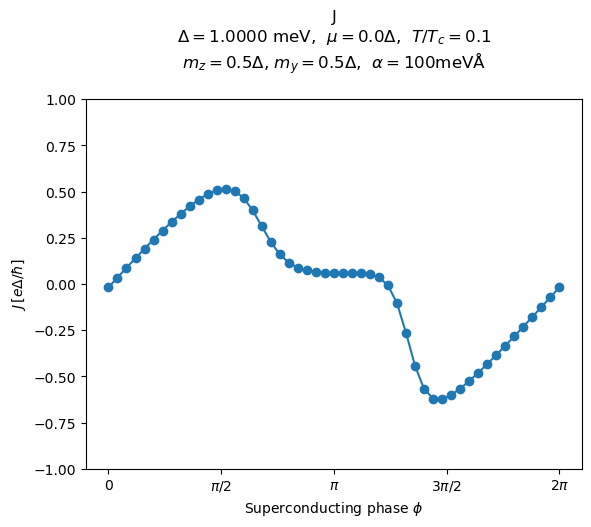

In [8]:
phi_list = np.linspace(0, 2*np.pi, 51)
J_list = []
for phi in phi_list:

    chaodaojiao = phi
    H_r = H_onsite(my,mz,3,chaodaojiao)
    Jphi = J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N, q)

    J_list.append(Jphi)

plt.figure()
plt.plot(phi_list, J_list, marker='o')
plt.xlabel(r'Superconducting phase $\phi$')
plt.ylabel(r'$J\,[e\Delta/\hbar]$')
plt.ylim(-1,1)
plt.xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
)
plt.title(
    f'J\n'
    f'$\\Delta = {dela:.4f}$ meV,  $\\mu = {mu/dela:.1f}\\Delta$,  $T/T_c = {T_Tc}$\n'
    f'$m_z = {mz}\\Delta$, $m_y = {my}\\Delta$,  $\\alpha = {af}$meVÅ\n'
    
)
plt.show()



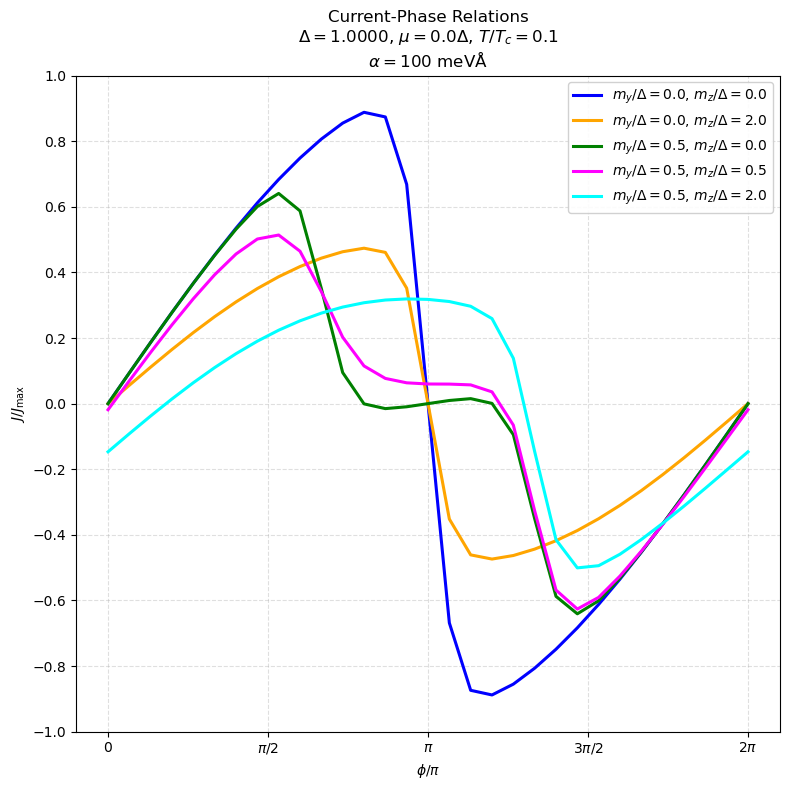

In [9]:
# 定义要画的 (my/Δ, mz/Δ) 组合，和论文图片 (b) 一致
parameter_sets = [
    (0.0, 0.0),   # 蓝色
    (0.0, 2.0),   # 橙色
    (0.5, 0.0),   # 绿色
    (0.5, 0.5),   # 粉色
    (0.5, 2.0),   # 青色
]

# 颜色列表（尽量接近论文风格）
colors = ['blue', 'orange', 'green', 'magenta', 'cyan']

# phi 网格
phi_list = np.linspace(0, 2 * np.pi, 31)
phi_plot = phi_list / np.pi   # x 轴用 φ/π

plt.figure(figsize=(8, 8))

all_J = []  # 用于后续可选归一化

for idx, (my_val, mz_val) in enumerate(parameter_sets):
    J_list = []
    
    for phi in phi_list:
        # 注意：这里只改右边的相位（标准做法）
        # 左边固定，中间不改相位
        H_l = H_onsite(my_val, mz_val, 1, 0.0)          # 左边相位固定 0
        H_q = H_onsite(my_val, mz_val, 2, 0.0)          # 中间无相位
        H_r = H_onsite(my_val, mz_val, 3, phi)          # 右边相位 = phi
        
        Jphi = J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N, q)
        J_list.append(Jphi)
    
    all_J.append(J_list)
    
    # 画这条曲线
    plt.plot(phi_plot, J_list,
             color=colors[idx],
             linewidth=2.2,
             label=f'$m_y/\\Delta = {my_val}$, $m_z/\\Delta = {mz_val}$')

# ------------------ 可选：全局归一化（让纵轴接近 [-1,1]，更像论文） ------------------
J_abs_max = max([max(map(abs, curve)) for curve in all_J])
if J_abs_max > 0:
    for i in range(len(all_J)):
        all_J[i] = [j / J_abs_max for j in all_J[i]]
    plt.ylabel(r'$J / J_{\max}$')
else:
    plt.ylabel(r'$J\,[2e/\beta\hbar]$')

# ------------------ 美化（模仿论文风格） ------------------
plt.xlabel(r'$\phi / \pi$')
plt.xticks([0, 0.5, 1, 1.5, 2],
           ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
plt.yticks(np.linspace(-1, 1, 11))
plt.ylim(-1, 1)

plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='upper right', fontsize=10, framealpha=0.9)
plt.title(
    f'Current-Phase Relations\n'
    f'$\\Delta = {dela:.4f}$, $\\mu = {mu/dela:.1f}\\Delta$, $T/T_c = {T_Tc}$\n'
    f'$\\alpha = {af}$ meVÅ'
)

plt.tight_layout()
plt.show()

my = 0.000, yinzi = 0.000000000014
my = 0.067, yinzi = 0.015392121882
my = 0.133, yinzi = 0.027650096345
my = 0.200, yinzi = 0.038191486914
my = 0.267, yinzi = 0.048531200678
my = 0.333, yinzi = 0.059633484256
my = 0.400, yinzi = 0.072382380408
my = 0.467, yinzi = 0.087876985130
my = 0.533, yinzi = 0.107701201654
my = 0.600, yinzi = 0.134306593769
my = 0.667, yinzi = 0.171560362417
my = 0.733, yinzi = 0.225107178057
my = 0.800, yinzi = 0.300163856250
my = 0.867, yinzi = 0.389343734536
my = 0.933, yinzi = 0.457377823503
my = 1.000, yinzi = 0.483841569057
my = 1.067, yinzi = 0.482401769940
my = 1.133, yinzi = 0.402908889702
my = 1.200, yinzi = 0.324770100598
my = 1.267, yinzi = 0.250595428174
my = 1.333, yinzi = 0.180337609870
my = 1.400, yinzi = 0.114298461554
my = 1.467, yinzi = 0.054307392269
my = 1.533, yinzi = 0.003391885776
my = 1.600, yinzi = 0.035258392874
my = 1.667, yinzi = 0.059625309136
my = 1.733, yinzi = 0.070185498988
my = 1.800, yinzi = 0.070339573087
my = 1.867, yinzi = 

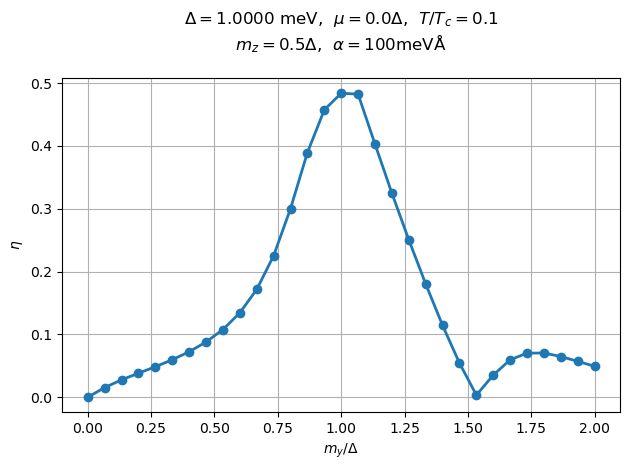

In [10]:
#my bian
my_list = np.linspace(0, 2, 31)
yinzi_list = np.zeros(len(my_list))

for i, my_val in enumerate(my_list):
    mz=0.5
    my=my_val
    J_max,_ , J_min,_, yinzi = find_J_extreme_fmin(phi_min=0, phi_max=2*np.pi,
                       N_guess=4, xtol=1e-3, ftol=1e-3,
                       round_digits=6)
    yinzi_list[i] = yinzi
    print(f"my = {my_val:.3f}, yinzi = {yinzi:.12f}")
    
plt.figure()
plt.plot(my_list/dela, yinzi_list, 'o-', linewidth=2)
plt.xlabel(r'$m_y$/$\Delta$')
plt.ylabel(r'$\eta$')
plt.title(
    f'$\\Delta = {dela:.4f}$ meV,  $\\mu = {mu/dela:.1f}\\Delta$,  $T/T_c = {T_Tc}$\n'
    f'$m_z = {mz}\\Delta$,  $\\alpha = {af}$meVÅ\n'
    
)
plt.grid(True)
plt.tight_layout()
plt.show()

mz = 0.000, yinzi = 0.000000000074
mz = 0.067, yinzi = 0.010455483282
mz = 0.133, yinzi = 0.042093895881
mz = 0.200, yinzi = 0.095347014636
mz = 0.267, yinzi = 0.169343409994
mz = 0.333, yinzi = 0.258575807046
mz = 0.400, yinzi = 0.347872672760
mz = 0.467, yinzi = 0.412158963161
mz = 0.533, yinzi = 0.434997625193
mz = 0.600, yinzi = 0.428581209182
mz = 0.667, yinzi = 0.412860744788
mz = 0.733, yinzi = 0.396709042521
mz = 0.800, yinzi = 0.382235960049
mz = 0.867, yinzi = 0.369600515802
mz = 0.933, yinzi = 0.358572062436
mz = 1.000, yinzi = 0.348894675373
mz = 1.067, yinzi = 0.340351791408
mz = 1.133, yinzi = 0.332767023448
mz = 1.200, yinzi = 0.325996333810
mz = 1.267, yinzi = 0.319921226704
mz = 1.333, yinzi = 0.314443601308
mz = 1.400, yinzi = 0.309481930111
mz = 1.467, yinzi = 0.304968112677
mz = 1.533, yinzi = 0.300845183414
mz = 1.600, yinzi = 0.297065320849
mz = 1.667, yinzi = 0.293587962616
mz = 1.733, yinzi = 0.290378785339
mz = 1.800, yinzi = 0.287408340639
mz = 1.867, yinzi = 

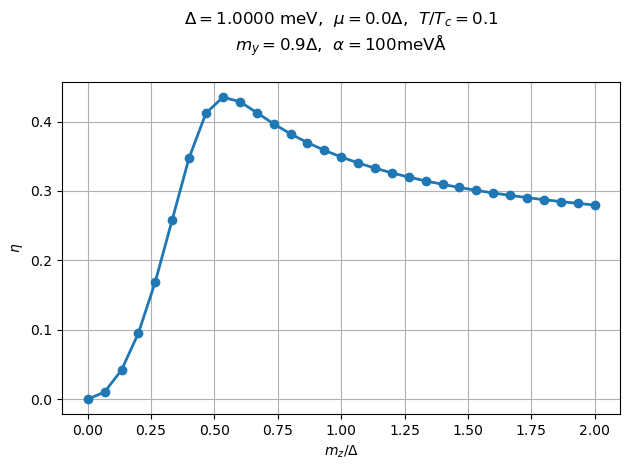

In [11]:
#mz bian
mz_list = np.linspace(0, 2, 31)
yinzi_list = np.zeros(len(mz_list))

for i, mz_val in enumerate(mz_list):
    my=0.9
    mz=mz_val
    J_max, _ ,J_min, _,yinzi = find_J_extreme_fmin(phi_min=0, phi_max=2*np.pi,
                       N_guess=4, xtol=1e-3, ftol=1e-3,
                       round_digits=6)

    yinzi_list[i] = yinzi

    print(f"mz = {mz_val:.3f}, yinzi = {yinzi:.12f}")



plt.figure()

plt.plot(mz_list/dela, yinzi_list, 'o-', linewidth=2)

plt.xlabel(r'$m_z$/$\Delta$')
plt.ylabel(r'$\eta$')
plt.title(
    f'$\\Delta = {dela:.4f}$ meV,  $\\mu = {mu/dela:.1f}\\Delta$,  $T/T_c = {T_Tc}$\n'
    f'$m_y = {my}\\Delta$,  $\\alpha = {af}$meVÅ\n'
    
)
plt.grid(True)
plt.tight_layout()
plt.show()